# Лабораторная работа №2: Прогнозирование временных рядов
**Задача:** Прогноз температуры на 7 дней вперед (многошаговый прогноз).

В этом ноутбуке реализованы все основные этапы согласно ТЗ и лекционным материалам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.fft import fft, fftfreq
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb
import optuna

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 1. Загрузка данных
- Использование `pd.ExcelFile`, чтобы увидеть скрытые листы.
- Загрузка только валидных листов, содержащих temperature_2m

In [2]:
file_path = 'weather_data.xlsx'

xl = pd.ExcelFile(file_path, engine='openpyxl')
print(f"Найдено листов в файле: {xl.sheet_names}")

dfs = {}
valid_sheets = []
skipped_sheets = []

for sheet_name in xl.sheet_names:
    df_sheet = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl')
    df_sheet = df_sheet.dropna(how='all', axis=1).dropna(how='all', axis=0)
    df_sheet.columns = (
        df_sheet.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
    if 'temperature_2m' in df_sheet.columns:
        df_sheet['_source_sheet'] = sheet_name
        dfs[sheet_name] = df_sheet
        valid_sheets.append(sheet_name)
    else:
        skipped_sheets.append(sheet_name)

print("\nЛисты с погодными данными (будут объединены):")
print(valid_sheets)
print("\nПропущенные листы (нет temperature_2m):")
print(skipped_sheets)

if len(dfs) == 0:
    raise ValueError("Не найдено ни одного листа с колонкой 'temperature_2m'")

df_raw = pd.concat(dfs.values(), ignore_index=True)
print(f"\nРазмер объединённого датафрейма: {df_raw.shape}")
print(f"Количество использованных листов: {len(valid_sheets)}")

Найдено листов в файле: ['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

Листы с погодными данными (будут объединены):
['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

Пропущенные листы (нет temperature_2m):
['Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!']

Размер объединённого датафрейма: (370577, 25)
Количество использованных листов: 3


## 2. Очистка и предобработка

### Работа с кодировками, ошибочными строками, опечатками

In [3]:
def fix_encoding(text):
    try:
        return str(text).encode('latin1').decode('cp1251')
    except:
        return str(text)

target_cols = [
    'ds', 'city', 'temperature_2m', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall',
    'wind_speed_10m', 'surface_pressure', 'weathercode'
]

existing_cols = [c for c in target_cols if c in df_raw.columns]
df = df_raw[existing_cols].copy()
print(f"Колонки, которые будут использоваться дальше: {existing_cols}")

df['city_raw']        = df['city']
df['city_decoded']    = df['city_raw'].apply(fix_encoding)
df['city_normalized'] = df['city_decoded'].astype('string').str.lower().str.strip()

print("\nГорода после расшифровки, но ДО исправления опечаток:")
display(
    df[['city_raw', 'city_decoded', 'city_normalized']]
    .drop_duplicates()
    .sort_values('city_normalized')
)

city_mapping = {
    'геленджик': 'Геленджик', 'геленджикк': 'Геленджик', 'геленджи': 'Геленджик',
    'благовещенск': 'Благовещенск', 'благовещенс': 'Благовещенск', 'благовещенскк': 'Благовещенск',
    'москва': 'Москва', 'мосва': 'Москва',
    'санкт-петербург': 'Санкт-Петербург',
    'находка': 'Находка',
    'сочи': 'Сочи', 'сычи': 'Сочи', 'счи': 'Сочи', 'соч': 'Сочи'
}

df['city_clean'] = df['city_normalized'].map(city_mapping)

unmapped_cities = (
    df[df['city_clean'].isna()]
    [['city_raw', 'city_decoded', 'city_normalized']]
    .drop_duplicates()
)
print("\nЗначения городов, которые НЕ удалось сопоставить:")
display(unmapped_cities)

before_rows = len(df)
df = df.dropna(subset=['city_clean']).copy()
print(f"\nУдалено строк без корректного города: {before_rows - len(df)}")

df['city'] = df['city_clean']
print("\nГорода после полной очистки:")
display(df['city'].value_counts().rename_axis('city').reset_index(name='rows_count'))

Колонки, которые будут использоваться дальше: ['ds', 'city', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'surface_pressure', 'weathercode']

Города после расшифровки, но ДО исправления опечаток:


,city_raw,city_decoded,city_normalized
125168,NaN,nan,nan
296,Áëàãîâåùåíñ,Благовещенс,благовещенс
1,Áëàãîâåùåíñê,Благовещенск,благовещенск
173,ÁËÀÃÎÂÅÙÅÍÑÊ,БЛАГОВЕЩЕНСК,благовещенск
674,áëàãîâåùåíñê,благовещенск,благовещенск
351,Áëàãîâåùåíñêê,Благовещенскк,благовещенскк
2114,Ãåëåíäæè,Геленджи,геленджи
0,Ãåëåíäæèê,Геленджик,геленджик
809,ÃÅËÅÍÄÆÈÊ,ГЕЛЕНДЖИК,геленджик
1103,ãåëåíäæèê,геленджик,геленджик



Значения городов, которые НЕ удалось сопоставить:


,city_raw,city_decoded,city_normalized
125168,NaN,nan,nan



Удалено строк без корректного города: 35

Города после полной очистки:


,city,rows_count
0,Благовещенск,62599
1,Геленджик,62525
2,Санкт-Петербург,61368
3,Сочи,61368
4,Москва,61365
5,Находка,61317


### Работа с типами данных, очистка выбросов, интерполяция для пропусков

Пропуски ДО обработки выбросов и интерполяции:
city                    0
ds                      0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
wind_speed_10m          0
surface_pressure        0
weathercode             0
dtype: int64
Найденные выбросы:
        ds            city  temp_before_outliers
2024-01-13          Москва            -27.941667
2024-01-03 Санкт-Петербург            -27.412500
2024-01-04 Санкт-Петербург            -26.869565
2024-01-04          Москва            -26.690909
2024-01-03          Москва            -26.175000
2024-01-05 Санкт-Петербург            -22.954167
2024-01-02 Санкт-Петербург            -22.866666

Всего найдено и удалено выбросов: 7


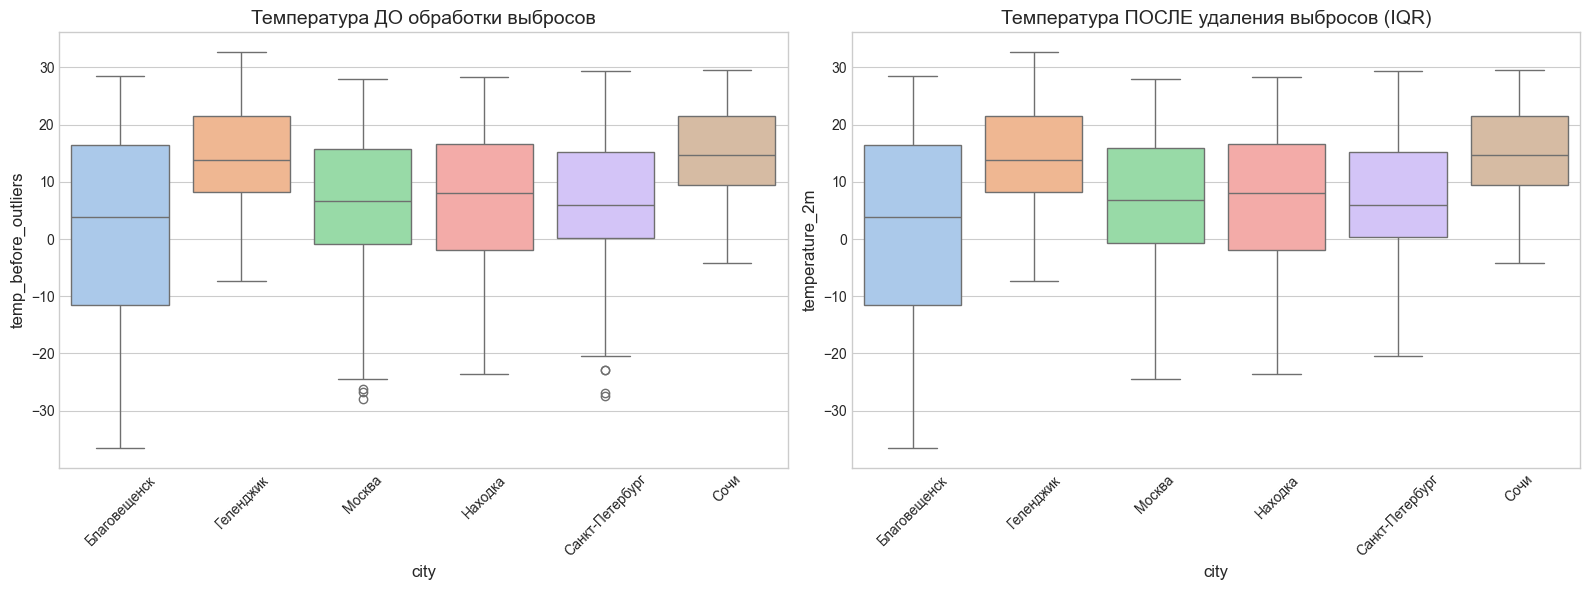


Пропуски ПОСЛЕ интерполяции:
city                    0
ds                      0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
wind_speed_10m          0
surface_pressure        0
weathercode             0
dtype: int64

Обработанный датафрейм: (15342, 10)


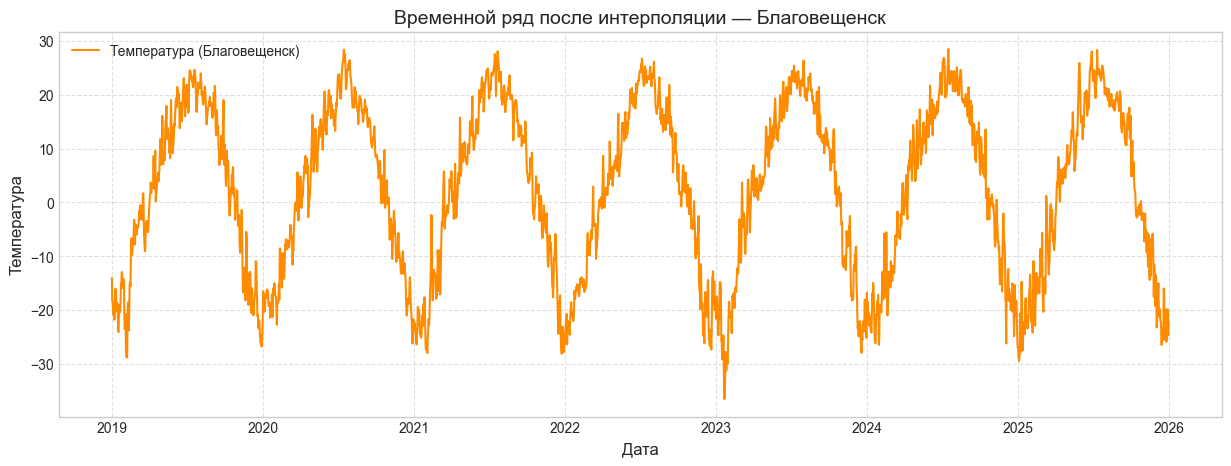

In [4]:
df['ds'] = pd.to_datetime(df['ds'])

# [ИСПРАВЛЕНО] rain и snowfall добавлены в агрегацию — ранее они молча терялись
agg_dict = {
    'temperature_2m':       'mean',
    'relative_humidity_2m': 'mean',
    'precipitation':        'sum',
    'rain':                 'sum',
    'snowfall':             'sum',
    'wind_speed_10m':       'mean',
    'surface_pressure':     'mean',
}
# [ИСПРАВЛЕНО] weathercode — берём моду (самый частый код за день)
# Добавляем отдельно, т.к. mode не поддерживается в agg напрямую через dict
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}
cols_to_numeric = list(agg_dict.keys())
if 'weathercode' in df.columns:
    cols_to_numeric.append('weathercode')

df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

df_daily = df.set_index('ds').groupby('city').resample('D').agg(agg_dict).reset_index()

# [ИСПРАВЛЕНО] weathercode агрегируем отдельно через моду
if 'weathercode' in df.columns:
    wc_daily = (
        df.set_index('ds')
        .groupby('city')
        .resample('D')['weathercode']
        .agg(lambda x: x.mode().iloc[0] if len(x.dropna()) > 0 else np.nan)
        .reset_index()
    )
    df_daily = df_daily.merge(wc_daily, on=['city', 'ds'], how='left')

print("Пропуски ДО обработки выбросов и интерполяции:")
print(df_daily.isna().sum())

df_daily['temp_before_outliers'] = df_daily['temperature_2m'].copy()

def remove_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)

df_daily['temperature_2m'] = df_daily.groupby('city')['temperature_2m'].transform(remove_outliers_iqr)

outliers_mask = df_daily['temp_before_outliers'].notna() & df_daily['temperature_2m'].isna()
outliers_df   = df_daily[outliers_mask]
print("Найденные выбросы:")
if not outliers_df.empty:
    print(outliers_df[['ds', 'city', 'temp_before_outliers']].sort_values('temp_before_outliers').to_string(index=False))
    print(f"\nВсего найдено и удалено выбросов: {len(outliers_df)}")
else:
    print("Выбросов не найдено.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df_daily, x='city', y='temp_before_outliers', ax=axes[0], palette='pastel')
axes[0].set_title('Температура ДО обработки выбросов'); axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df_daily, x='city', y='temperature_2m', ax=axes[1], palette='pastel')
axes[1].set_title('Температура ПОСЛЕ удаления выбросов (IQR)'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

def interpolate_group(group):
    return group.interpolate(method='linear').bfill().ffill()

numeric_interp_cols = [c for c in cols_to_numeric if c in df_daily.columns]
df_daily[numeric_interp_cols] = df_daily.groupby('city', group_keys=False)[numeric_interp_cols].apply(interpolate_group)
# weathercode — заполняем методом ffill (нельзя интерполировать категориальные коды)
if 'weathercode' in df_daily.columns:
    df_daily['weathercode'] = df_daily.groupby('city')['weathercode'].transform(lambda x: x.ffill().bfill())

df_daily = df_daily.drop(columns=['temp_before_outliers'])

print("\nПропуски ПОСЛЕ интерполяции:")
print(df_daily.isna().sum())
print(f"\nОбработанный датафрейм: {df_daily.shape}")

sample_city = df_daily['city'].iloc[0]
city_data   = df_daily[df_daily['city'] == sample_city]
plt.figure(figsize=(15, 5))
plt.plot(city_data['ds'], city_data['temperature_2m'], color='darkorange', label=f'Температура ({sample_city})')
plt.title(f'Временной ряд после интерполяции — {sample_city}')
plt.xlabel('Дата'); plt.ylabel('Температура'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Анализ (EDA)
Проверка стационарности и декомпозиция.

### [ИСПРАВЛЕНО] EDA теперь проводится по всем 6 городам, а не только по Москве

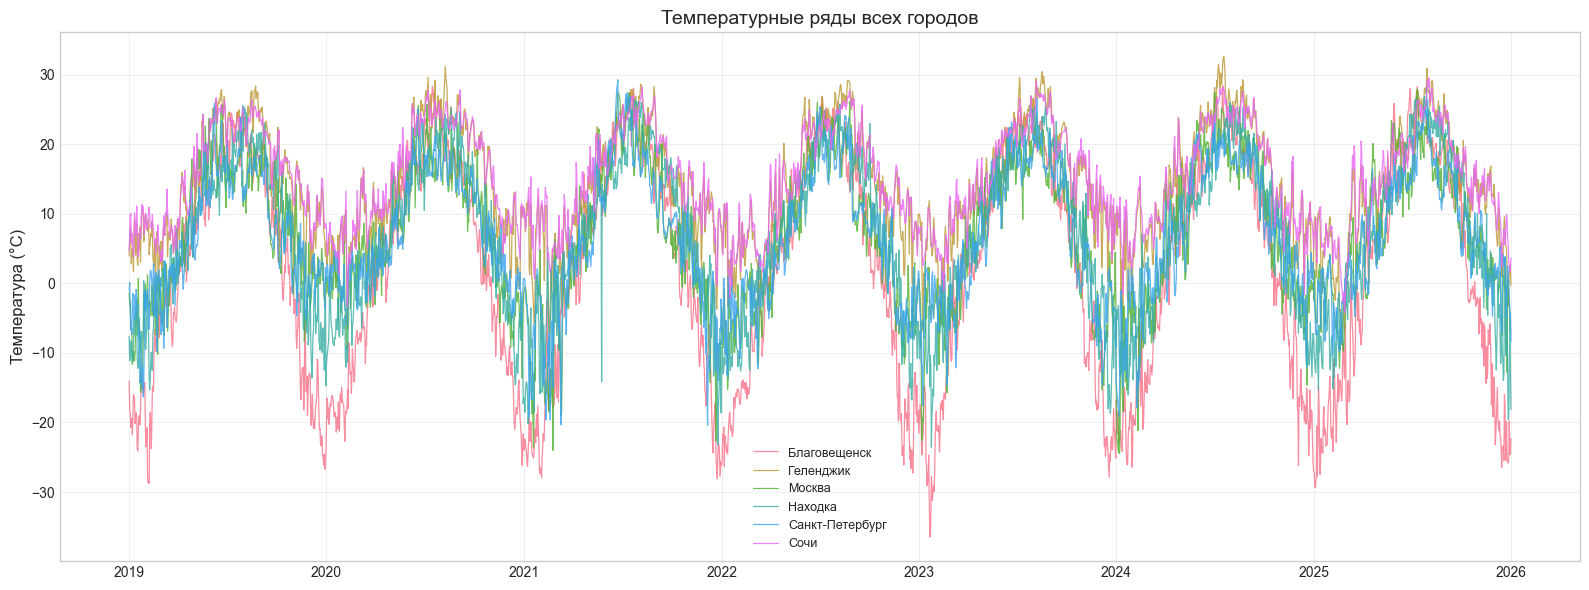

In [5]:
# Сравнение всех городов на одном графике
all_cities = df_daily['city'].unique()
plt.figure(figsize=(16, 6))
for city in all_cities:
    d = df_daily[df_daily['city'] == city]
    plt.plot(d['ds'], d['temperature_2m'], label=city, alpha=0.8, linewidth=0.9)
plt.title('Температурные ряды всех городов')
plt.ylabel('Температура (°C)'); plt.legend(fontsize=9); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

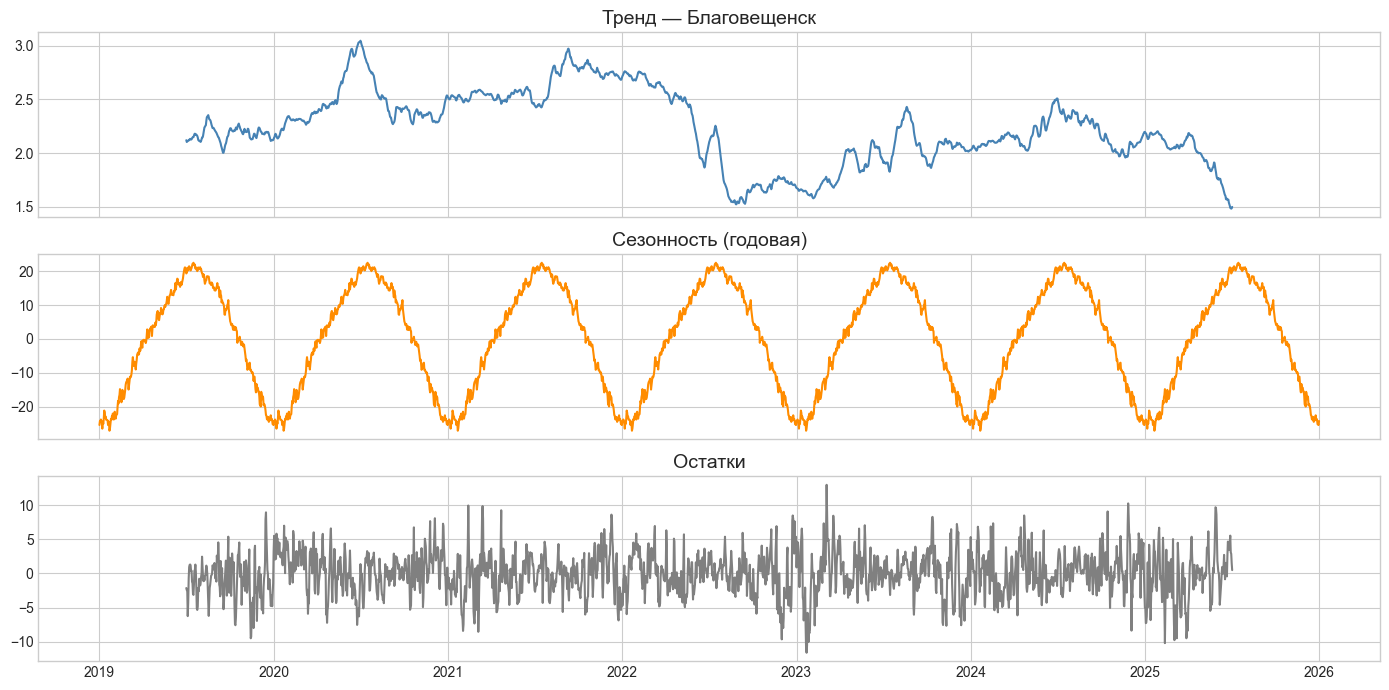

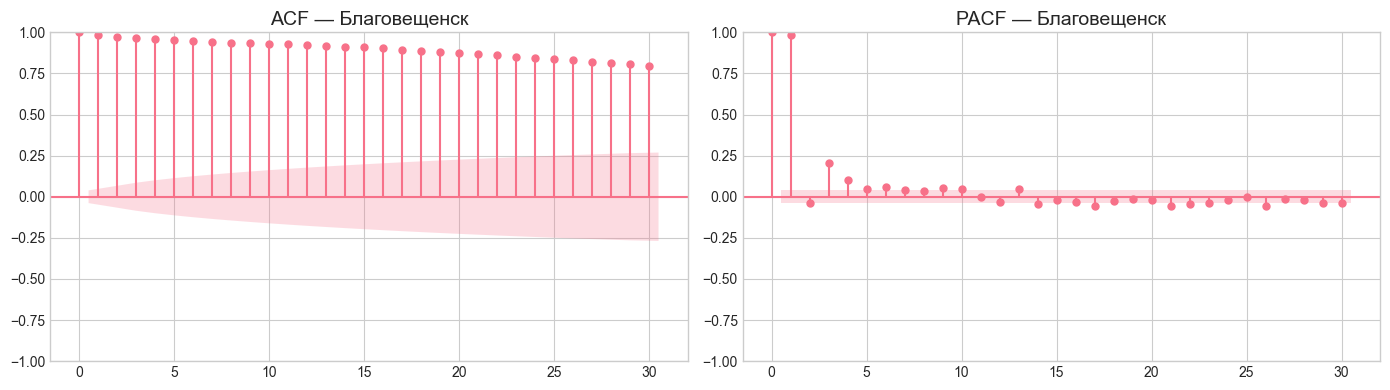

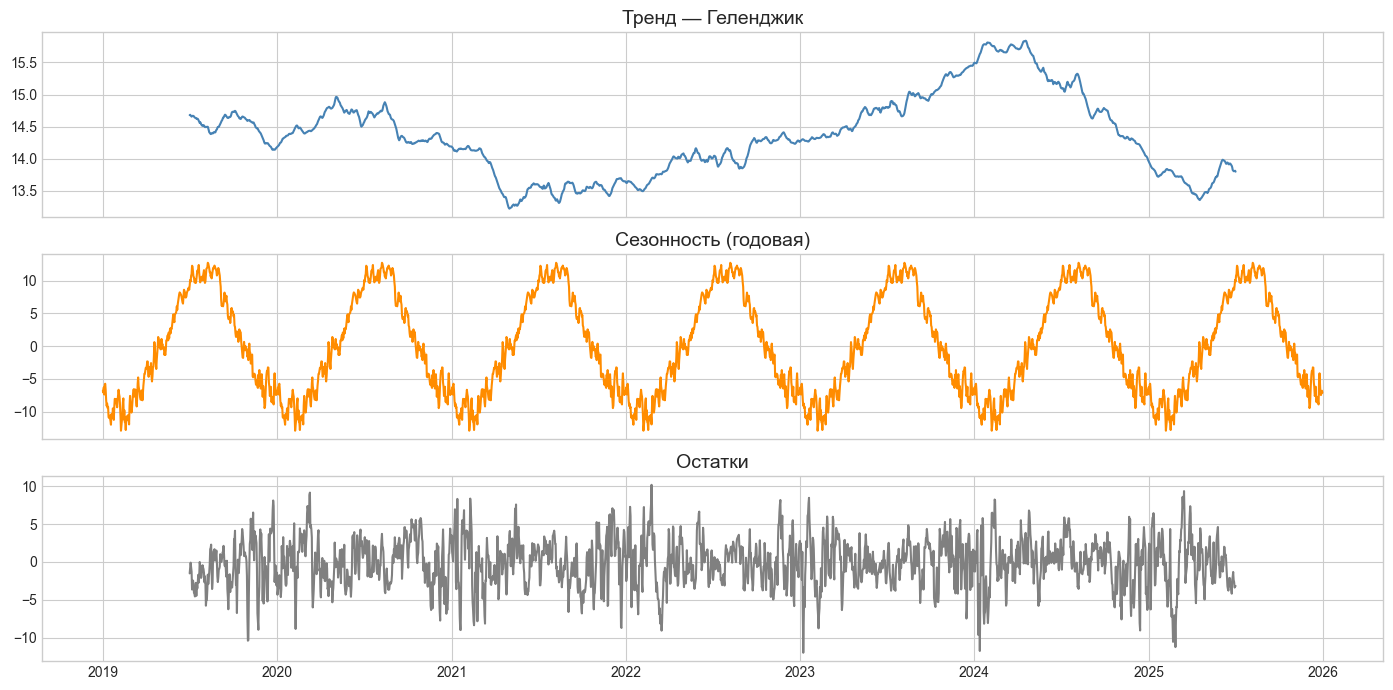

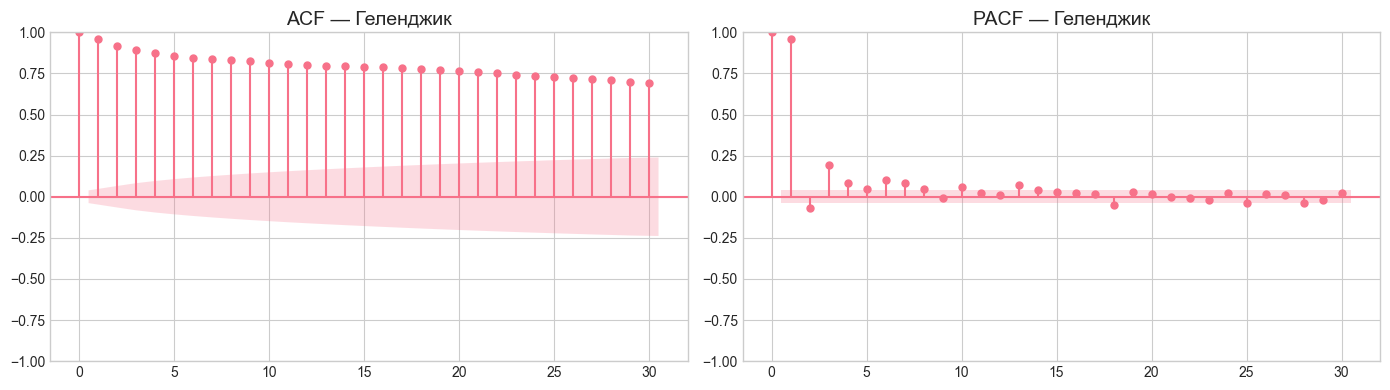

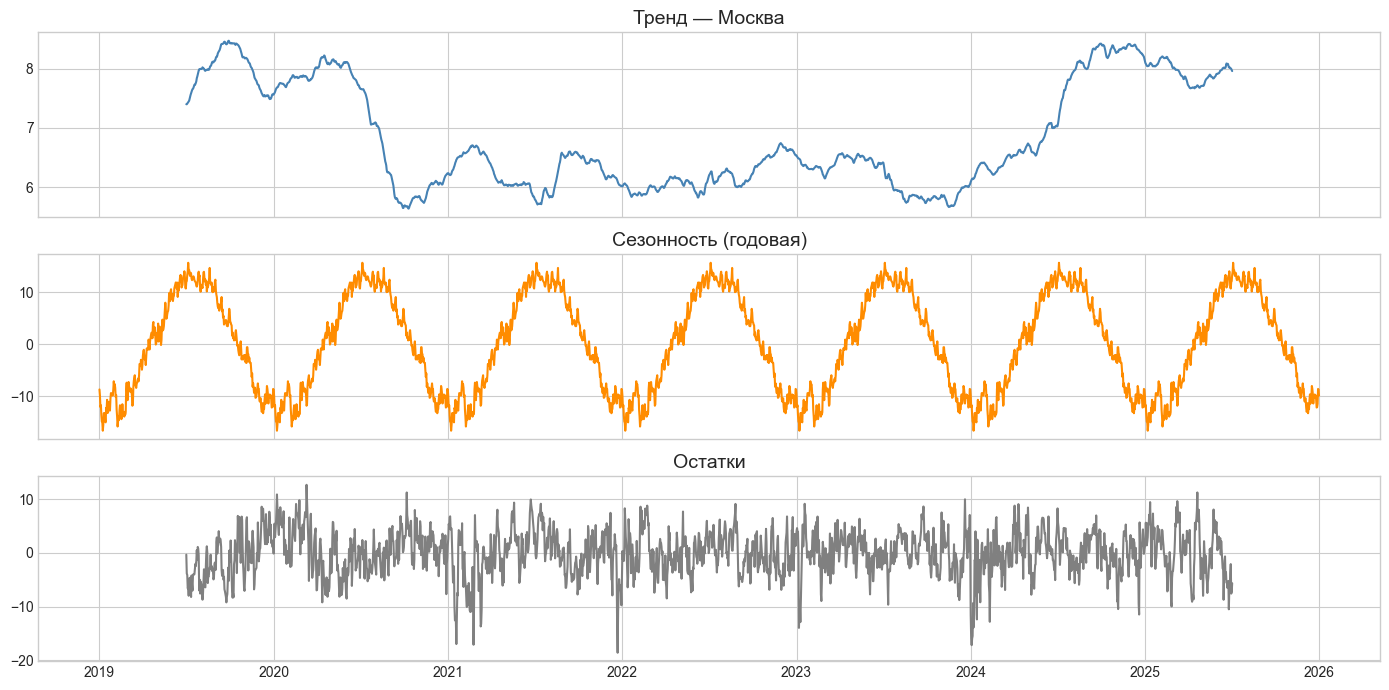

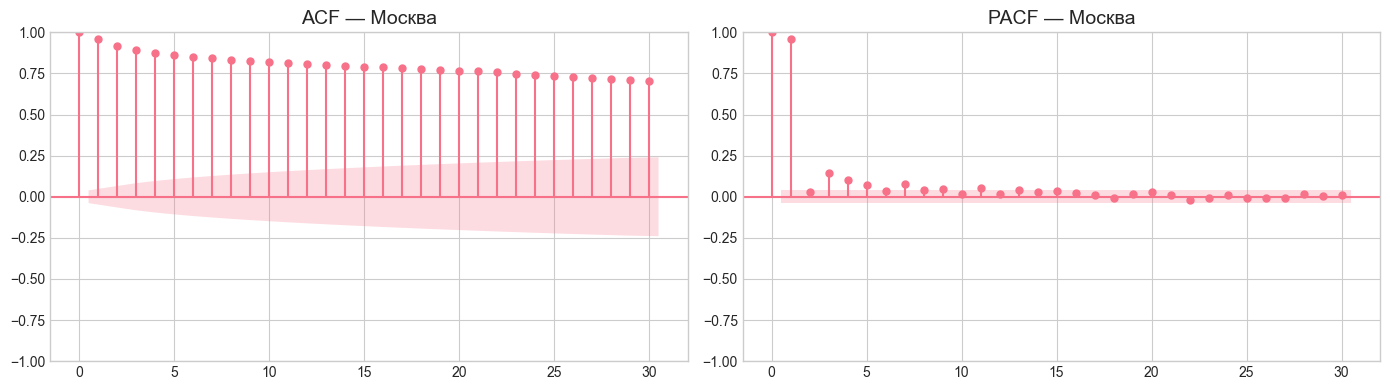

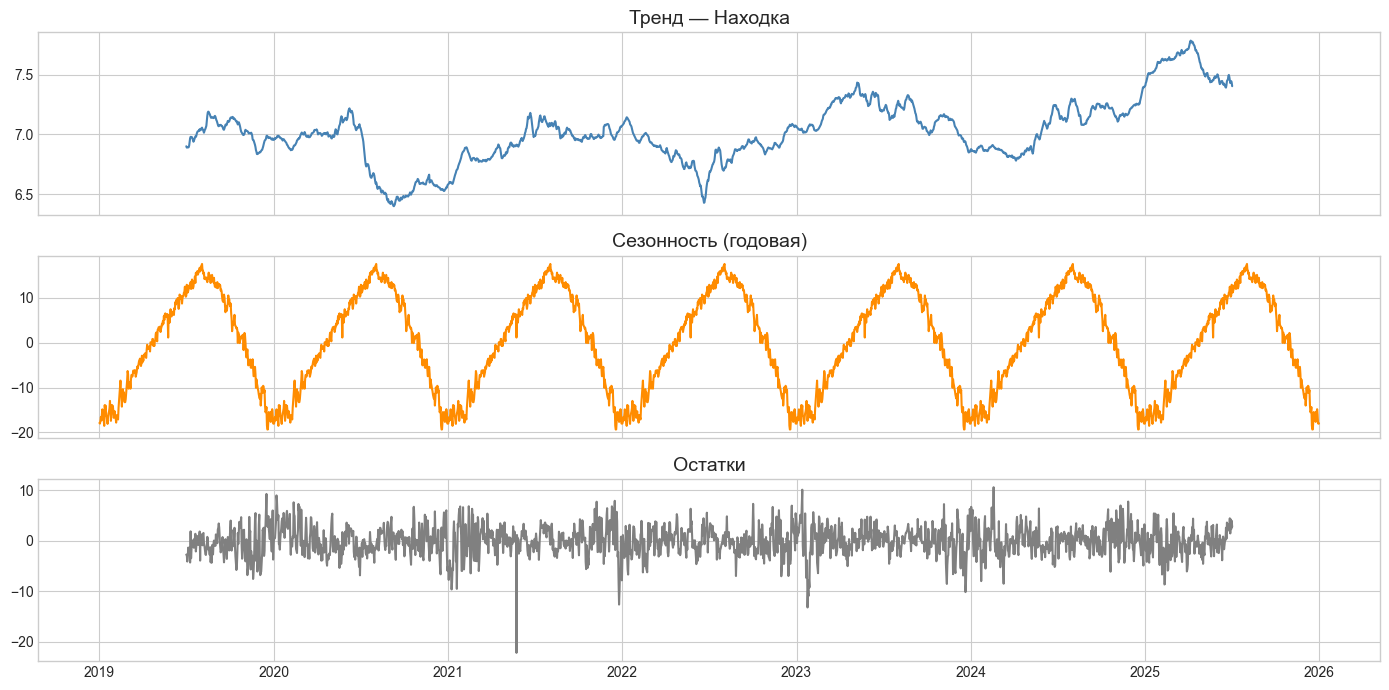

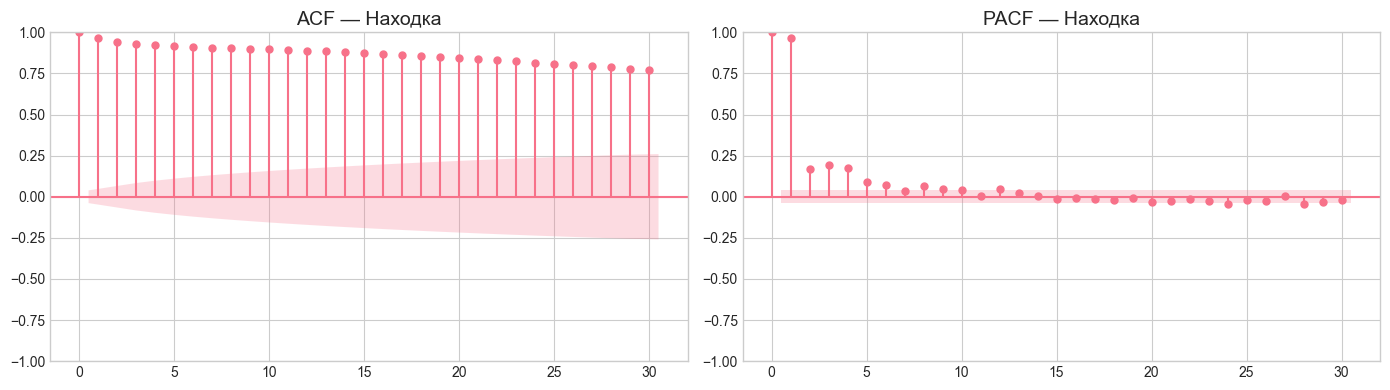

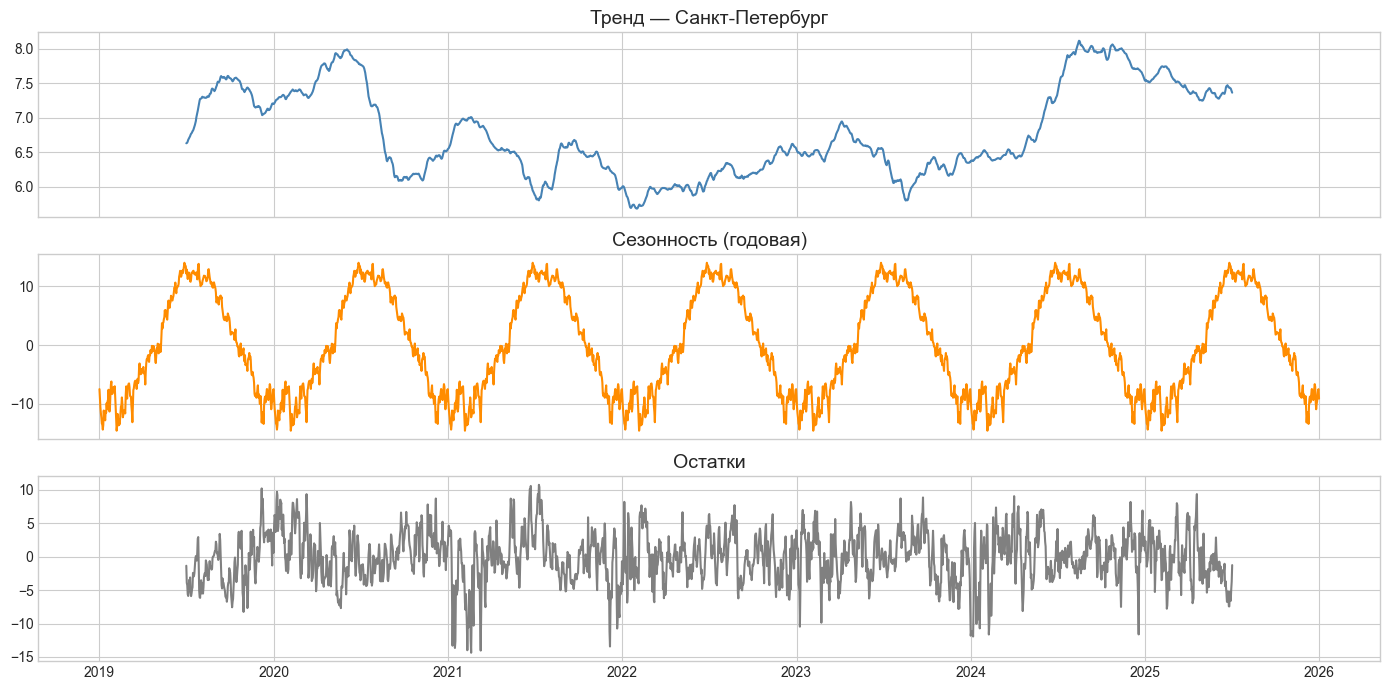

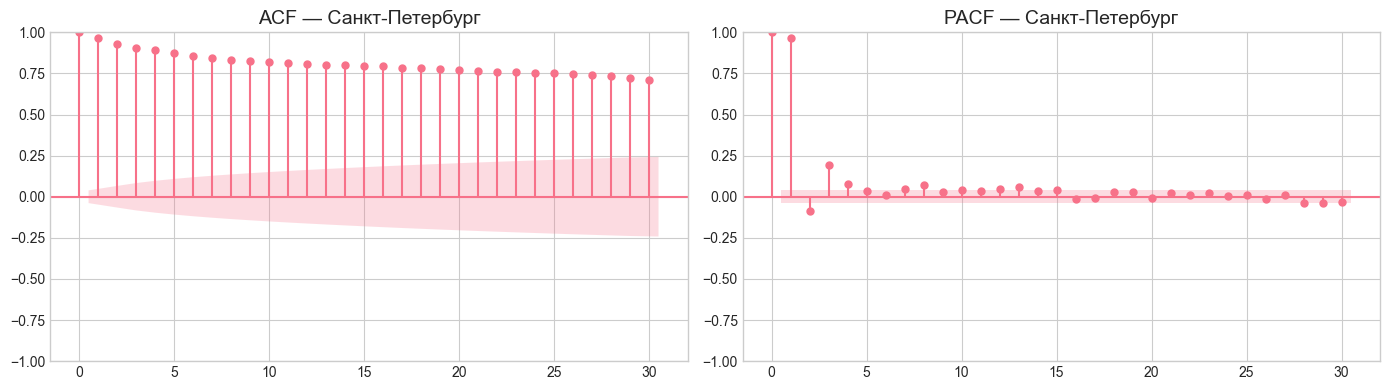

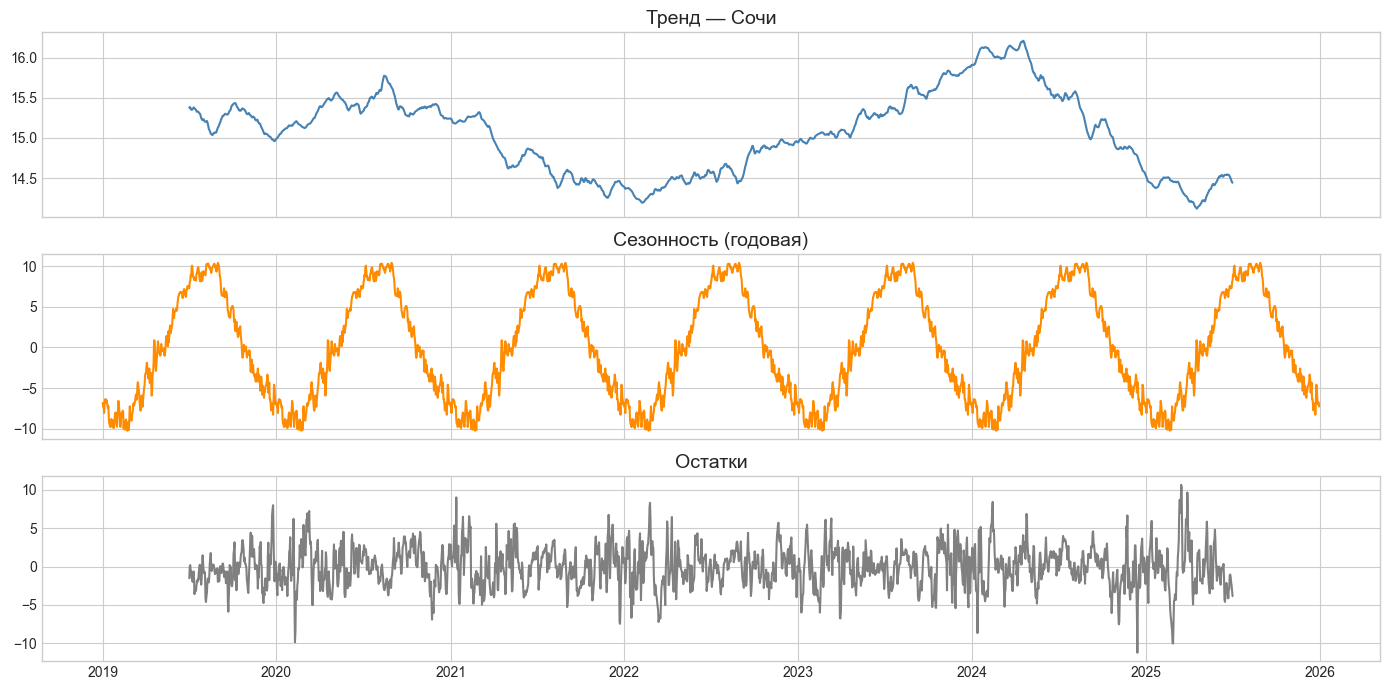

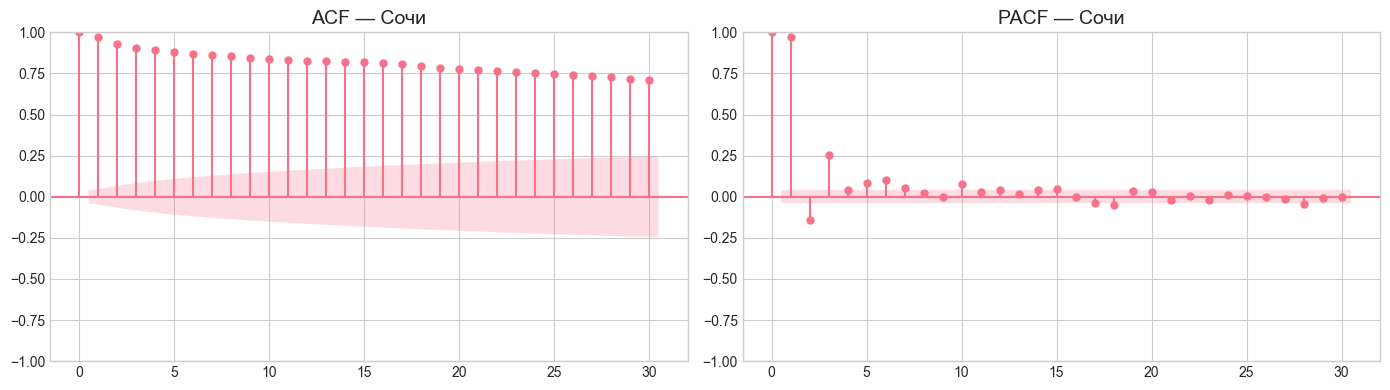


Сводная таблица теста Дики-Фуллера по всем городам:


,Город,ADF stat,p-value,Стационарен
0,Благовещенск,-3.3311,0.01354,Да
1,Геленджик,-3.0110,0.03388,Да
2,Москва,-3.1683,0.02190,Да
3,Находка,-2.3677,0.15106,Нет
4,Санкт-Петербург,-3.1513,0.02298,Да
5,Сочи,-3.0047,0.03446,Да


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# [ИСПРАВЛЕНО] ADF-тест, декомпозиция, ACF/PACF — по всем городам
adf_results = []

for city in all_cities:
    df_city = df_daily[df_daily['city'] == city].set_index('ds').sort_index()
    series  = df_city['temperature_2m']

    # --- ADF тест ---
    adf_stat, adf_p, *_ = adfuller(series)
    adf_results.append({
        'Город': city,
        'ADF stat': round(adf_stat, 4),
        'p-value': round(adf_p, 5),
        'Стационарен': 'Да' if adf_p < 0.05 else 'Нет'
    })

    # --- Декомпозиция ---
    decompose = seasonal_decompose(series, model='additive', period=365)
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(decompose.trend,    color='steelblue');  axes[0].set_title(f'Тренд — {city}')
    axes[1].plot(decompose.seasonal, color='darkorange'); axes[1].set_title('Сезонность (годовая)')
    axes[2].plot(decompose.resid,    color='gray');       axes[2].set_title('Остатки')
    plt.tight_layout(); plt.show()

    # --- ACF / PACF ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf( series, lags=30, ax=axes[0], title=f'ACF — {city}')
    plot_pacf(series, lags=30, ax=axes[1], title=f'PACF — {city}')
    plt.tight_layout(); plt.show()

# Сводная таблица ADF
print("\nСводная таблица теста Дики-Фуллера по всем городам:")
display(pd.DataFrame(adf_results))

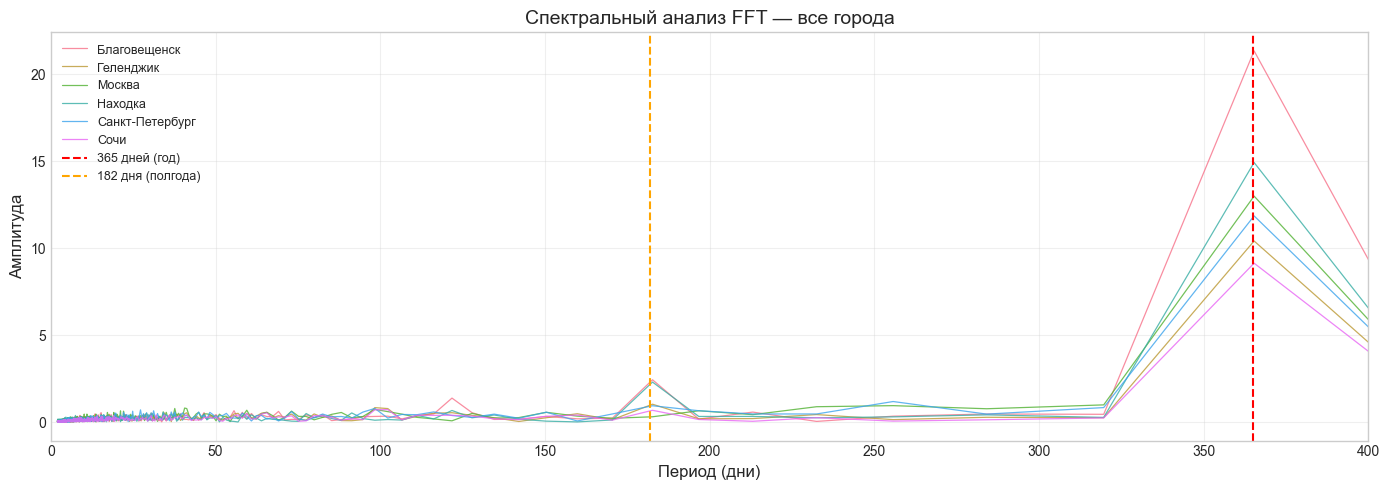

Топ-3 доминирующих периода по городам:
  Благовещенск: 365 дн. (amp=21.35), 183 дн. (amp=2.43), 122 дн. (amp=1.38)
  Геленджик: 365 дн. (amp=10.41), 183 дн. (amp=1.03), 98 дн. (amp=0.83)
  Москва: 365 дн. (amp=13.00), 2557 дн. (amp=0.99), 320 дн. (amp=0.99)
  Находка: 365 дн. (amp=14.93), 183 дн. (amp=2.30), 122 дн. (amp=0.66)
  Санкт-Петербург: 365 дн. (amp=11.86), 256 дн. (amp=1.18), 183 дн. (amp=0.94)
  Сочи: 365 дн. (amp=9.14), 102 дн. (amp=0.71), 98 дн. (amp=0.70)


In [7]:
# [ИСПРАВЛЕНО] FFT — по всем городам, сравнительный график амплитуд
fig, ax = plt.subplots(figsize=(14, 5))

for city in all_cities:
    series = df_daily[df_daily['city'] == city].set_index('ds')['temperature_2m'].values
    N      = len(series)
    yf     = fft(series)
    xf     = fftfreq(N, d=1)
    pos    = xf > 0
    periods    = 1.0 / xf[pos]
    amplitudes = 2.0 / N * np.abs(yf[pos])
    ax.plot(periods, amplitudes, label=city, alpha=0.8, linewidth=0.9)

ax.set_xlim(0, 400)
ax.axvline(x=365, color='red',    linestyle='--', label='365 дней (год)')
ax.axvline(x=182, color='orange', linestyle='--', label='182 дня (полгода)')
ax.set_title('Спектральный анализ FFT — все города')
ax.set_xlabel('Период (дни)'); ax.set_ylabel('Амплитуда')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Топ-3 периода по каждому городу
print("Топ-3 доминирующих периода по городам:")
for city in all_cities:
    series = df_daily[df_daily['city'] == city].set_index('ds')['temperature_2m'].values
    N   = len(series)
    yf  = fft(series); xf = fftfreq(N, d=1)
    pos = xf > 0
    periods    = 1.0 / xf[pos]
    amplitudes = 2.0 / N * np.abs(yf[pos])
    top3       = np.argsort(amplitudes)[::-1][:3]
    print(f"  {city}: " + ", ".join([f"{periods[i]:.0f} дн. (amp={amplitudes[i]:.2f})" for i in top3]))

## 4. Feature Engineering

### [ИСПРАВЛЕНО] Добавлены признаки из weathercode, rain, snowfall
- `weathercode` → бинарные флаги групп явлений (ясно / облачно / осадки / снег / гроза)
- `rain`, `snowfall` → лаги и rolling-статистики
- `snow_flag` — был ли снег (бинарный)
- `rain_flag` — был ли дождь (бинарный)

In [8]:
def create_features(df, max_horizon=7):
    df = df.copy().sort_values(['city', 'ds']).reset_index(drop=True)

    # --- Календарные признаки ---
    df['month']     = df['ds'].dt.month
    df['dayofyear'] = df['ds'].dt.dayofyear

    # --- Fourier-признаки (k=1,2,3) ---
    for k in range(1, 4):
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['dayofyear'] / 365.25)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['dayofyear'] / 365.25)

    # --- Лаги температуры ---
    for lag in range(1, 15):
        df[f'temp_lag_{lag}'] = df.groupby('city')['temperature_2m'].shift(lag)
    df['temp_lag_365'] = df.groupby('city')['temperature_2m'].shift(365)

    # --- Лаги других числовых погодных параметров ---
    other_weather_cols = ['relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'surface_pressure']
    other_weather_cols = [c for c in other_weather_cols if c in df.columns]
    for col in other_weather_cols:
        for lag in [1, 2, 7]:
            df[f'{col}_lag_{lag}'] = df.groupby('city')[col].shift(lag)

    # [НОВОЕ] --- Признаки из rain и snowfall ---
    if 'rain' in df.columns:
        for lag in [1, 2, 7]:
            df[f'rain_lag_{lag}'] = df.groupby('city')['rain'].shift(lag)
        # Скользящая сумма дождей за 7 дней (были ли затяжные дожди)
        df['rain_roll_sum_7'] = df.groupby('city')['rain'].transform(
            lambda x: x.shift(1).rolling(7).sum()
        )
        # Бинарный флаг: шёл ли дождь вчера
        df['rain_flag_lag1'] = (df.groupby('city')['rain'].shift(1) > 0).astype(int)

    if 'snowfall' in df.columns:
        for lag in [1, 2, 7]:
            df[f'snowfall_lag_{lag}'] = df.groupby('city')['snowfall'].shift(lag)
        # Скользящая сумма снега за 7 дней (лежит ли снежный покров)
        df['snow_roll_sum_7'] = df.groupby('city')['snowfall'].transform(
            lambda x: x.shift(1).rolling(7).sum()
        )
        # Бинарный флаг: шёл ли снег вчера
        df['snow_flag_lag1'] = (df.groupby('city')['snowfall'].shift(1) > 0).astype(int)

    # [НОВОЕ] --- Признаки из weathercode ---
    # WMO-группы: дерево решений умеет работать с числами, но бинарные флаги
    # снимают проблему нелинейности кодов и делают связь явной
    if 'weathercode' in df.columns:
        wc = df.groupby('city')['weathercode'].shift(1)  # берём вчерашний код
        df['wc_lag1_clear']        = (wc == 0).astype(int)           # ясно
        df['wc_lag1_cloudy']       = wc.between(1, 3).astype(int)    # переменная облачность
        df['wc_lag1_fog']          = wc.between(45, 48).astype(int)  # туман
        df['wc_lag1_drizzle']      = wc.between(51, 57).astype(int)  # морось
        df['wc_lag1_rain']         = wc.between(61, 67).astype(int)  # дождь
        df['wc_lag1_snow']         = wc.between(71, 77).astype(int)  # снег
        df['wc_lag1_shower']       = wc.between(80, 82).astype(int)  # ливни
        df['wc_lag1_snow_shower']  = wc.between(85, 86).astype(int)  # снежные ливни
        df['wc_lag1_thunderstorm'] = wc.between(95, 99).astype(int)  # гроза
        # Числовой лаг кода тоже оставляем — для дерева может быть полезен
        df['wc_lag1_raw'] = wc

    # --- Rolling статистики по температуре ---
    df['temp_roll_mean_7']  = df.groupby('city')['temp_lag_1'].transform(lambda x: x.rolling(7).mean())
    df['temp_roll_std_7']   = df.groupby('city')['temp_lag_1'].transform(lambda x: x.rolling(7).std())
    df['temp_roll_mean_30'] = df.groupby('city')['temp_lag_1'].transform(lambda x: x.rolling(30).mean())
    df['temp_roll_std_30']  = df.groupby('city')['temp_lag_1'].transform(lambda x: x.rolling(30).std())

    # --- Interaction Features ---
    df['temp_x_humidity'] = df['temp_lag_1'] * df.get('relative_humidity_2m_lag_1', 0)
    df['pressure_diff_1'] = df.get('surface_pressure_lag_1', 0) - df.get('surface_pressure_lag_2', 0)
    df['precip_x_temp']   = df.get('precipitation_lag_1', 0) * df['temp_lag_1']

    # --- Целевые переменные (Direct Strategy) ---
    for h in range(1, max_horizon + 1):
        df[f'target_h{h}'] = df.groupby('city')['temperature_2m'].shift(-h)

    # --- Удаление текущих значений (предотвращение data leakage) ---
    drop_cols = other_weather_cols.copy()
    for c in ['rain', 'snowfall', 'weathercode']:
        if c in df.columns:
            drop_cols.append(c)
    df = df.drop(columns=drop_cols, errors='ignore')

    # --- One-Hot Encoding города ---
    df = pd.get_dummies(df, columns=['city'], drop_first=False)

    # --- Удаление строк с NaN ---
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean


print("Создание признаков...")
df_feat = create_features(df_daily, max_horizon=7)

target_cols_list  = [c for c in df_feat.columns if c.startswith('target_h')]
city_cols         = [c for c in df_feat.columns if c.startswith('city_')]
wc_flag_cols      = [c for c in df_feat.columns if c.startswith('wc_lag1_')]
rain_snow_cols    = [c for c in df_feat.columns if 'rain_' in c or 'snow_' in c]

print(f"\nРазмер исходного датасета:        {df_daily.shape[0]:,} × {df_daily.shape[1]}")
print(f"Размер после Feature Engineering: {df_feat.shape[0]:,} × {df_feat.shape[1]}")
print(f"\nПризнаки weathercode (флаги):     {len(wc_flag_cols)} шт. → {wc_flag_cols}")
print(f"Признаки rain/snowfall:            {len(rain_snow_cols)} шт.")
print(f"Всего признаков для модели (X):   {df_feat.shape[1] - len(target_cols_list) - 2}")
print(f"Пропусков: {df_feat.isnull().sum().sum()}")

Создание признаков...

Размер исходного датасета:        15,342 × 10
Размер после Feature Engineering: 13,110 × 77

Признаки weathercode (флаги):     10 шт. → ['wc_lag1_clear', 'wc_lag1_cloudy', 'wc_lag1_fog', 'wc_lag1_drizzle', 'wc_lag1_rain', 'wc_lag1_snow', 'wc_lag1_shower', 'wc_lag1_snow_shower', 'wc_lag1_thunderstorm', 'wc_lag1_raw']
Признаки rain/snowfall:            8 шт.
Всего признаков для модели (X):   68
Пропусков: 0


### Корреляция новых погодных признаков с температурой

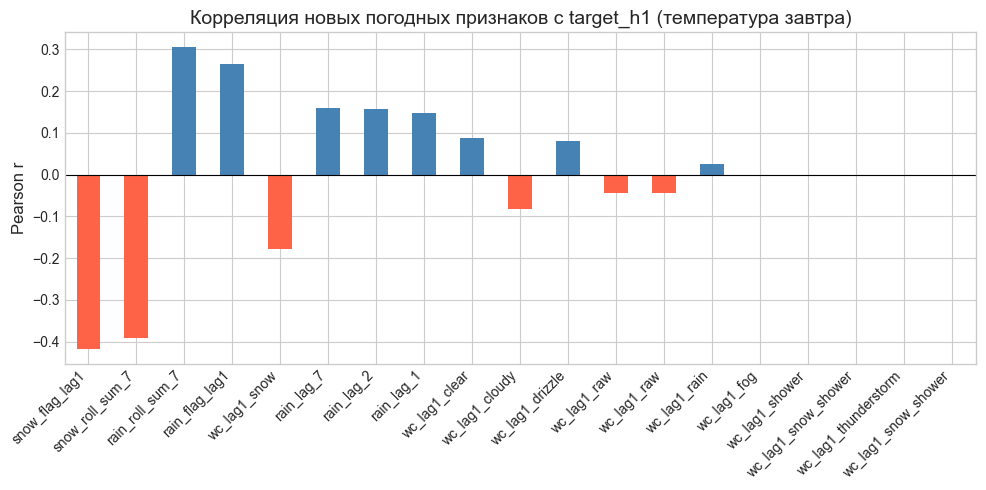


Корреляции (убывание по модулю):
snow_flag_lag1         -0.4161
snow_roll_sum_7        -0.3916
rain_roll_sum_7         0.3046
rain_flag_lag1          0.2637
wc_lag1_snow           -0.1779
rain_lag_7              0.1603
rain_lag_2              0.1562
rain_lag_1              0.1474
wc_lag1_clear           0.0872
wc_lag1_cloudy         -0.0819
wc_lag1_drizzle         0.0801
wc_lag1_raw            -0.0436
wc_lag1_raw            -0.0436
wc_lag1_rain            0.0252
wc_lag1_fog                NaN
wc_lag1_shower             NaN
wc_lag1_snow_shower        NaN
wc_lag1_thunderstorm       NaN
wc_lag1_snow_shower        NaN


In [9]:
# [НОВОЕ] Проверяем корреляцию новых признаков с target_h1
new_weather_feats = wc_flag_cols + rain_snow_cols + ['wc_lag1_raw'] if 'wc_lag1_raw' in df_feat.columns else wc_flag_cols + rain_snow_cols
new_weather_feats = [c for c in new_weather_feats if c in df_feat.columns]

corr_series = df_feat[new_weather_feats + ['target_h1']].corr()['target_h1'].drop('target_h1').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
corr_series.plot(kind='bar', color=['steelblue' if v > 0 else 'tomato' for v in corr_series])
plt.title('Корреляция новых погодных признаков с target_h1 (температура завтра)')
plt.ylabel('Pearson r')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nКорреляции (убывание по модулю):")
print(corr_series.round(4).to_string())

# 5. Разбиение и Метрики

In [10]:
df_feat = df_feat.sort_values(['ds']).reset_index(drop=True)

unique_dates      = np.sort(df_feat['ds'].unique())
train_cutoff_date = unique_dates[int(len(unique_dates) * 0.70)]
val_cutoff_date   = unique_dates[int(len(unique_dates) * 0.85)]

train = df_feat[df_feat['ds'] <= train_cutoff_date].copy()
val   = df_feat[(df_feat['ds'] > train_cutoff_date) & (df_feat['ds'] <= val_cutoff_date)].copy()
test  = df_feat[df_feat['ds'] > val_cutoff_date].copy()

print("Размеры выборок:")
print(f"Train: {train.shape[0]}  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Val:   {val.shape[0]}   ({val['ds'].min().date()} → {val['ds'].max().date()})")
print(f"Test:  {test.shape[0]}   ({test['ds'].min().date()} → {test['ds'].max().date()})")

assert train['ds'].max() < val['ds'].min()
assert val['ds'].max()   < test['ds'].min()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calc_metrics(y_true, y_pred, y_prev):
    y_true, y_pred, y_prev = np.array(y_true), np.array(y_pred), np.array(y_prev)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    dir_true = np.sign(y_true - y_prev)
    dir_pred = np.sign(y_pred - y_prev)
    da       = np.mean(dir_true == dir_pred) * 100
    dir_true_bin = (dir_true > 0).astype(int)
    dir_pred_bin = (dir_pred > 0).astype(int)
    dir_r2 = r2_score(dir_true_bin, dir_pred_bin) if len(np.unique(dir_true_bin)) > 1 else 0.0
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'WAPE (%)': wape, 'MAPE (%)': mape,
            'DirAcc (%)': da, 'DirR2': dir_r2, 'R2': r2}

target_cols_list = [c for c in df_feat.columns if c.startswith('target_h')]
features = [c for c in df_feat.columns if c not in ['ds', 'temperature_2m'] + target_cols_list]
print(f"\nКоличество признаков (features): {len(features)}")
print(f"Целевые переменные: {target_cols_list}")

Размеры выборок:
Train: 9180  (2020-01-01 → 2024-03-09)
Val:   1968   (2024-03-10 → 2025-01-31)
Test:  1962   (2025-02-01 → 2025-12-24)

Количество признаков (features): 68
Целевые переменные: ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6', 'target_h7']


## 6. Наивный прогноз (Baseline)

In [11]:
import lightgbm as lgb
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

baseline_results = []
for h in range(1, 8):
    y_true = test[f'target_h{h}'].values
    y_pred = test['temp_lag_1'].values
    y_prev = test['temp_lag_1'].values
    m = calc_metrics(y_true, y_pred, y_prev)
    m['Horizon'] = h; m['Model'] = 'Naive (lag_1)'
    baseline_results.append(m)

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df[['Model', 'Horizon', 'MAE', 'RMSE', 'DirAcc (%)']].to_string(index=False))

        Model  Horizon      MAE     RMSE  DirAcc (%)
Naive (lag_1)        1 2.453626 3.284648         0.0
Naive (lag_1)        2 2.798537 3.716271         0.0
Naive (lag_1)        3 3.066749 4.009608         0.0
Naive (lag_1)        4 3.380421 4.355587         0.0
Naive (lag_1)        5 3.601288 4.649773         0.0
Naive (lag_1)        6 3.750837 4.867667         0.0
Naive (lag_1)        7 3.884146 5.036067         0.0


## 7. Optuna — подбор гиперпараметров для всех трёх моделей

In [12]:
# ── Optuna для LightGBM ───────────────────────────────────────────────────
def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state': 42, 'verbose': -1
    }
    total_mae = 0
    for h in range(1, 8):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            train[features], train[f'target_h{h}'],
            eval_set=[(val[features], val[f'target_h{h}'])],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        total_mae += mean_absolute_error(val[f'target_h{h}'], model.predict(val[features]))
    return total_mae / 7

print("Подбор гиперпараметров LightGBM (Optuna)...")
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
best_lgb_params = {**study_lgb.best_params, 'random_state': 42, 'verbose': -1}
print(f"\nЛучшие параметры LightGBM: {best_lgb_params}")
print(f"Лучший средний MAE (val):   {study_lgb.best_value:.4f}")

Подбор гиперпараметров LightGBM (Optuna)...


  0%|          | 0/30 [00:00<?, ?it/s]


Лучшие параметры LightGBM: {'n_estimators': 331, 'learning_rate': 0.046934031756264254, 'max_depth': 3, 'num_leaves': 57, 'min_child_samples': 27, 'subsample': 0.6126486621390769, 'colsample_bytree': 0.7260816349048711, 'reg_alpha': 0.003628294690625194, 'reg_lambda': 0.06719418872918778, 'random_state': 42, 'verbose': -1}
Лучший средний MAE (val):   2.5074


In [13]:
# ── Optuna для Decision Tree ──────────────────────────────────────────────
def objective_dt(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    total_mae = 0
    for h in range(1, 8):
        model = DecisionTreeRegressor(**params)
        model.fit(train[features], train[f'target_h{h}'])
        total_mae += mean_absolute_error(val[f'target_h{h}'], model.predict(val[features]))
    return total_mae / 7

print("Подбор гиперпараметров Decision Tree (Optuna)...")
study_dt = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=30, show_progress_bar=True)
best_dt_params = {**study_dt.best_params, 'random_state': 42}
print(f"\nЛучшие параметры Decision Tree: {best_dt_params}")
print(f"Лучший средний MAE (val):        {study_dt.best_value:.4f}")

Подбор гиперпараметров Decision Tree (Optuna)...


  0%|          | 0/30 [00:00<?, ?it/s]


Лучшие параметры Decision Tree: {'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': None, 'random_state': 42}
Лучший средний MAE (val):        2.8756


In [14]:
# ── Optuna для Random Forest ──────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 400),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42, 'n_jobs': -1
    }
    total_mae = 0
    for h in range(1, 8):
        model = RandomForestRegressor(**params)
        model.fit(train[features], train[f'target_h{h}'])
        total_mae += mean_absolute_error(val[f'target_h{h}'], model.predict(val[features]))
    return total_mae / 7

print("Подбор гиперпараметров Random Forest (Optuna)...")
study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
best_rf_params = {**study_rf.best_params, 'random_state': 42, 'n_jobs': -1}
print(f"\nЛучшие параметры Random Forest: {best_rf_params}")
print(f"Лучший средний MAE (val):        {study_rf.best_value:.4f}")

Подбор гиперпараметров Random Forest (Optuna)...


  0%|          | 0/20 [00:00<?, ?it/s]


Лучшие параметры Random Forest: {'n_estimators': 300, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 42, 'n_jobs': -1}
Лучший средний MAE (val):        2.5416


In [15]:
# Сравнение результатов Optuna
optuna_summary = pd.DataFrame([
    {'Модель': 'LightGBM',      'Лучший MAE (val)': round(study_lgb.best_value, 4), 'n_trials': 30},
    {'Модель': 'Decision Tree', 'Лучший MAE (val)': round(study_dt.best_value,  4), 'n_trials': 30},
    {'Модель': 'Random Forest', 'Лучший MAE (val)': round(study_rf.best_value,  4), 'n_trials': 20},
]).sort_values('Лучший MAE (val)')
print("\nОптимизация Optuna — итог:")
print(optuna_summary.to_string(index=False))


Оптимизация Optuna — итог:
       Модель  Лучший MAE (val)  n_trials
     LightGBM            2.5074        30
Random Forest            2.5416        20
Decision Tree            2.8756        30


## 8. Direct Strategy — обучение моделей

In [16]:
# Финальное обучение на train + val
train_full = pd.concat([train, val], ignore_index=True)

print("=" * 60)
print("Обучение моделей (Direct Strategy)")
print(f"Обучение на train+val: {len(train_full)} строк")
print("=" * 60)

direct_lgb = {}
for h in range(1, 8):
    model = lgb.LGBMRegressor(**best_lgb_params)
    model.fit(train_full[features], train_full[f'target_h{h}'])
    direct_lgb[h] = model
print("LightGBM Direct обучен")

direct_dt = {}
for h in range(1, 8):
    model = DecisionTreeRegressor(**best_dt_params)
    model.fit(train_full[features], train_full[f'target_h{h}'])
    direct_dt[h] = model
print("Decision Tree Direct обучен")

direct_rf = {}
for h in range(1, 8):
    model = RandomForestRegressor(**best_rf_params)
    model.fit(train_full[features], train_full[f'target_h{h}'])
    direct_rf[h] = model
print("Random Forest Direct обучен")

Обучение моделей (Direct Strategy)
Обучение на train+val: 11148 строк
LightGBM Direct обучен
Decision Tree Direct обучен
Random Forest Direct обучен


## 9. Recursive Strategy

In [17]:
def recursive_forecast(model, test_df, features, horizon=7):
    curr_df = test_df.copy()
    preds   = np.zeros((len(curr_df), horizon))
    for h in range(horizon):
        pred = model.predict(curr_df[features])
        preds[:, h] = pred
        for i in range(14, 1, -1):
            col, col_prev = f'temp_lag_{i}', f'temp_lag_{i-1}'
            if col in curr_df.columns and col_prev in curr_df.columns:
                curr_df[col] = curr_df[col_prev]
        curr_df['temp_lag_1'] = pred
    return preds

dt_recursive = DecisionTreeRegressor(**best_dt_params)
dt_recursive.fit(train_full[features], train_full['target_h1'])
dt_recursive_preds = recursive_forecast(dt_recursive, test, features)
print("Decision Tree Recursive обучен и предсказан")

rf_recursive = RandomForestRegressor(**best_rf_params)
rf_recursive.fit(train_full[features], train_full['target_h1'])
rf_recursive_preds = recursive_forecast(rf_recursive, test, features)
print("Random Forest Recursive обучен и предсказан")

lgb_recursive = lgb.LGBMRegressor(**best_lgb_params)
lgb_recursive.fit(train_full[features], train_full['target_h1'])
lgb_recursive_preds = recursive_forecast(lgb_recursive, test, features)
print("LightGBM Recursive обучен и предсказан")

Decision Tree Recursive обучен и предсказан
Random Forest Recursive обучен и предсказан
LightGBM Recursive обучен и предсказан


## 10. Таблица результатов

In [18]:
all_results = []
for h in range(1, 8):
    y_true = test[f'target_h{h}'].values
    y_prev = test['temp_lag_1'].values
    models_preds = {
        'Naive (lag_1)':  test['temp_lag_1'].values,
        'DT Direct':      direct_dt[h].predict(test[features]),
        'RF Direct':      direct_rf[h].predict(test[features]),
        'LGBM Direct':    direct_lgb[h].predict(test[features]),
        'DT Recursive':   dt_recursive_preds[:, h-1],
        'RF Recursive':   rf_recursive_preds[:, h-1],
        'LGBM Recursive': lgb_recursive_preds[:, h-1],
    }
    for model_name, y_pred in models_preds.items():
        m = calc_metrics(y_true, y_pred, y_prev)
        m['Horizon'] = h; m['Model'] = model_name
        all_results.append(m)

results_df = pd.DataFrame(all_results)

for h in range(1, 8):
    print(f"\nГоризонт h={h}")
    subset = results_df[results_df['Horizon'] == h][['Model', 'MAE', 'RMSE', 'WAPE (%)', 'MAPE (%)', 'DirAcc (%)', 'DirR2', 'R2']]
    print(subset.to_string(index=False))


Горизонт h=1
         Model      MAE     RMSE  WAPE (%)   MAPE (%)  DirAcc (%)     DirR2       R2
 Naive (lag_1) 2.453626 3.284648 19.287863  72.365118    0.000000 -0.981818 0.906742
     DT Direct 2.549700 3.337378 20.043094 107.228837   56.982671 -0.720838 0.903724
     RF Direct 2.358482 3.076479 18.539940  68.348944   61.926606 -0.523064 0.918188
   LGBM Direct 2.223778 2.911507 17.481037  63.724490   63.047910 -0.478208 0.926727
  DT Recursive 2.549700 3.337378 20.043094 107.228837   56.982671 -0.720838 0.903724
  RF Recursive 2.358482 3.076479 18.539940  68.348944   61.926606 -0.523064 0.918188
LGBM Recursive 2.223778 2.911507 17.481037  63.724490   63.047910 -0.478208 0.926727

Горизонт h=2
         Model      MAE     RMSE  WAPE (%)   MAPE (%)  DirAcc (%)     DirR2       R2
 Naive (lag_1) 2.798537 3.716271 21.993659 109.875677    0.000000 -0.956132 0.881074
     DT Direct 2.880753 3.762876 22.639787 100.124841   59.887870 -0.605293 0.878073
     RF Direct 2.632145 3.408506 20.6

## 11. Сводная таблица (среднее по h1–h7)

In [19]:
summary = results_df.groupby('Model')[['MAE', 'RMSE', 'WAPE (%)', 'MAPE (%)', 'DirAcc (%)', 'DirR2', 'R2']].mean()
summary = summary.sort_values('MAE')
print(summary.round(3).to_string())

                  MAE   RMSE  WAPE (%)  MAPE (%)  DirAcc (%)  DirR2     R2
Model                                                                     
LGBM Direct     2.771  3.572    21.784   129.525      67.555 -0.298  0.889
RF Direct       2.817  3.636    22.140   122.549      66.565 -0.338  0.886
RF Recursive    2.852  3.702    22.417   125.371      65.764 -0.370  0.881
LGBM Recursive  2.878  3.732    22.624   127.607      65.494 -0.381  0.879
DT Direct       3.132  4.052    24.623   156.110      63.274 -0.470  0.858
DT Recursive    3.149  4.091    24.757   159.095      59.983 -0.602  0.855
Naive (lag_1)   3.277  4.274    25.756   139.961       0.000 -0.964  0.840


## 12. Визуализация

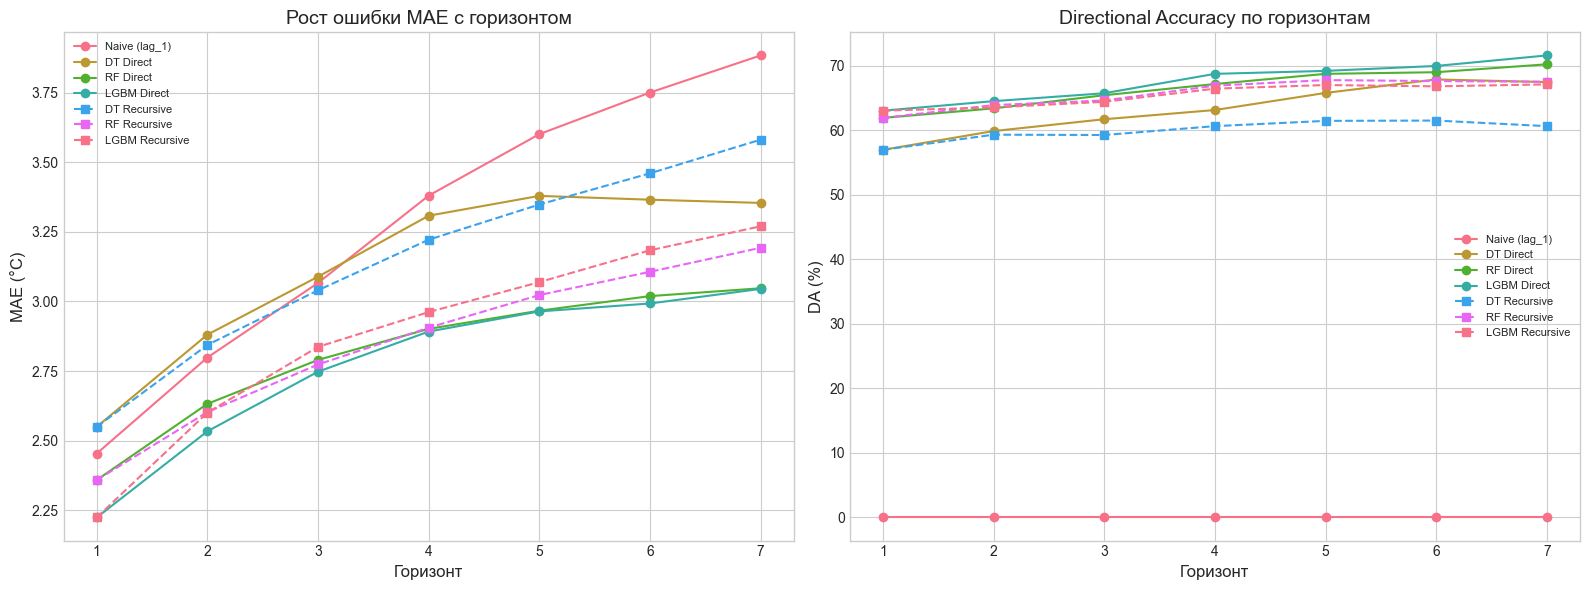

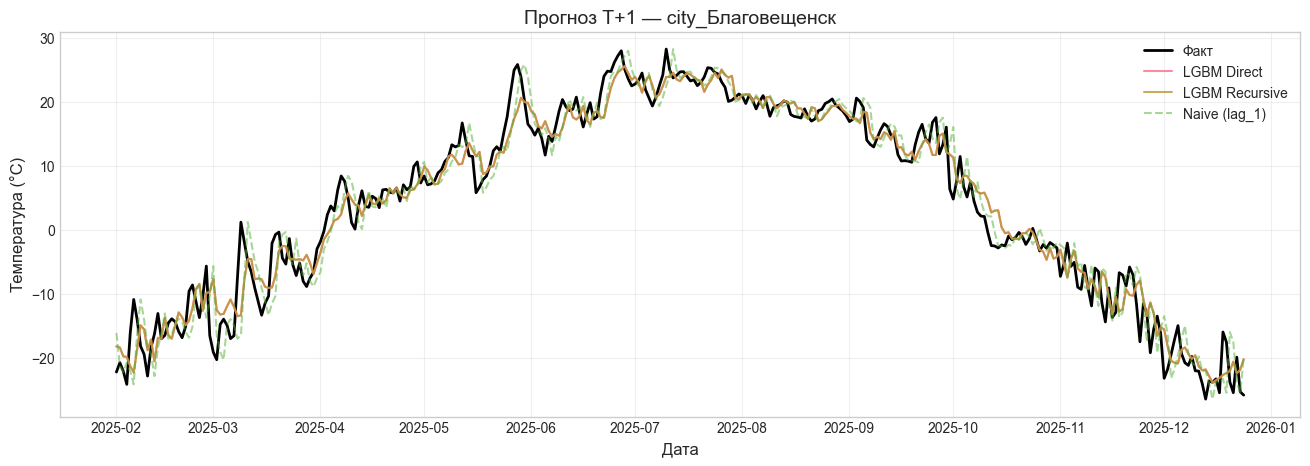

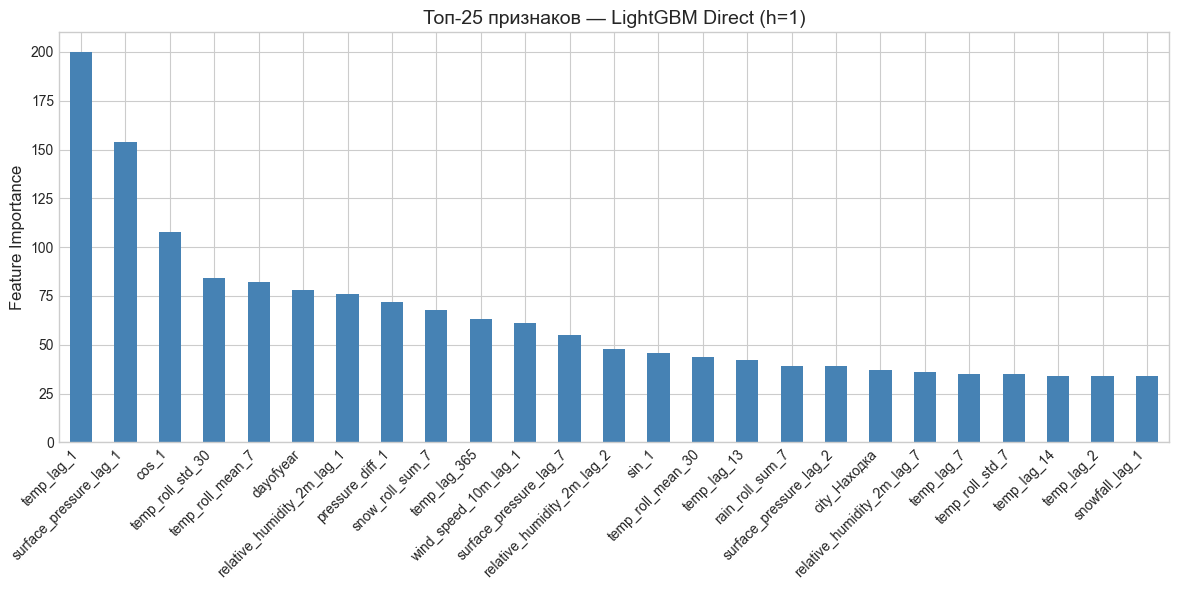

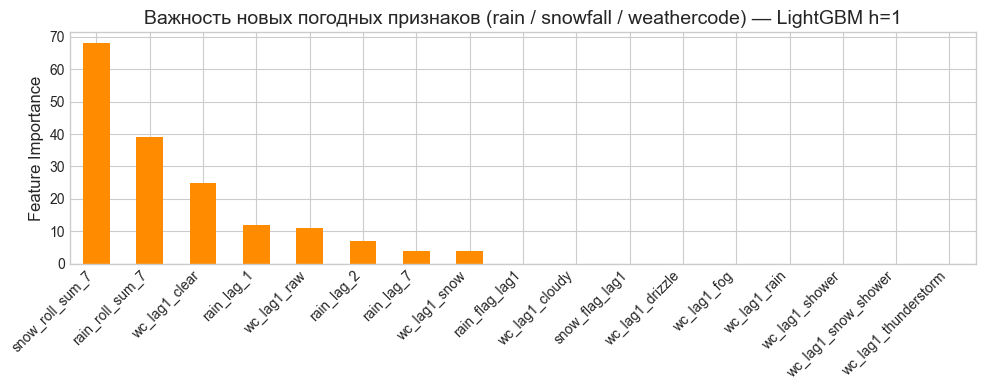

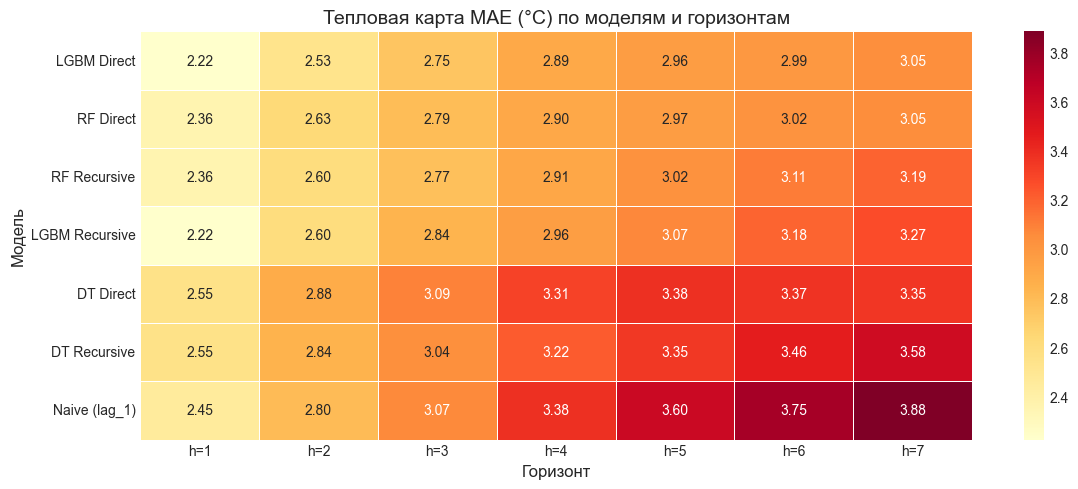

In [20]:
# 1. MAE и DirAcc по горизонтам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model_name in ['Naive (lag_1)', 'DT Direct', 'RF Direct', 'LGBM Direct',
                   'DT Recursive', 'RF Recursive', 'LGBM Recursive']:
    subset    = results_df[results_df['Model'] == model_name]
    ls        = '--' if 'Recursive' in model_name else '-'
    marker    = 'o' if 'Direct' in model_name or 'Naive' in model_name else 's'
    axes[0].plot(subset['Horizon'], subset['MAE'],        marker=marker, linestyle=ls, label=model_name)
    axes[1].plot(subset['Horizon'], subset['DirAcc (%)'], marker=marker, linestyle=ls, label=model_name)
axes[0].set_title('Рост ошибки MAE с горизонтом'); axes[0].set_xlabel('Горизонт'); axes[0].set_ylabel('MAE (°C)'); axes[0].legend(fontsize=8)
axes[1].set_title('Directional Accuracy по горизонтам'); axes[1].set_xlabel('Горизонт'); axes[1].set_ylabel('DA (%)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# 2. Прогноз vs Факт
city_col  = [c for c in test.columns if c.startswith('city_')][0]
mask      = test[city_col] == 1
h_plot    = 1
dates_plot      = test['ds'].values[mask]
y_true_plot     = test[f'target_h{h_plot}'].values[mask]
y_lgbm_direct   = direct_lgb[h_plot].predict(test[features])[mask]
y_lgbm_rec      = lgb_recursive_preds[:, h_plot-1][mask]
y_naive         = test['temp_lag_1'].values[mask]

plt.figure(figsize=(16, 5))
plt.plot(dates_plot, y_true_plot,   label='Факт',          color='black', linewidth=2)
plt.plot(dates_plot, y_lgbm_direct, label='LGBM Direct',   alpha=0.8)
plt.plot(dates_plot, y_lgbm_rec,    label='LGBM Recursive', alpha=0.8)
plt.plot(dates_plot, y_naive,       label='Naive (lag_1)',  alpha=0.5, linestyle='--')
plt.title(f'Прогноз T+{h_plot} — {city_col}')
plt.xlabel('Дата'); plt.ylabel('Температура (°C)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# 3. Feature Importance LightGBM (h=1) — топ-25
feat_imp = pd.Series(direct_lgb[1].feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
feat_imp.head(25).plot(kind='bar', color='steelblue')
plt.title('Топ-25 признаков — LightGBM Direct (h=1)')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# [НОВОЕ] 4. Feature Importance: только новые погодные признаки
new_cols_in_model = [c for c in features if c.startswith('wc_lag1_') or 'rain_' in c or 'snow_' in c]
if new_cols_in_model:
    feat_imp_new = feat_imp[new_cols_in_model].sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    feat_imp_new.plot(kind='bar', color='darkorange')
    plt.title('Важность новых погодных признаков (rain / snowfall / weathercode) — LightGBM h=1')
    plt.ylabel('Feature Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()

# 5. Тепловая карта MAE
pivot_mae = results_df.pivot(index='Model', columns='Horizon', values='MAE').loc[summary.index]
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_mae, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'h={h}' for h in range(1, 8)], linewidths=0.5)
plt.title('Тепловая карта MAE (°C) по моделям и горизонтам')
plt.ylabel('Модель'); plt.xlabel('Горизонт')
plt.tight_layout(); plt.show()

## 13. Анализ остатков (Residual Analysis)

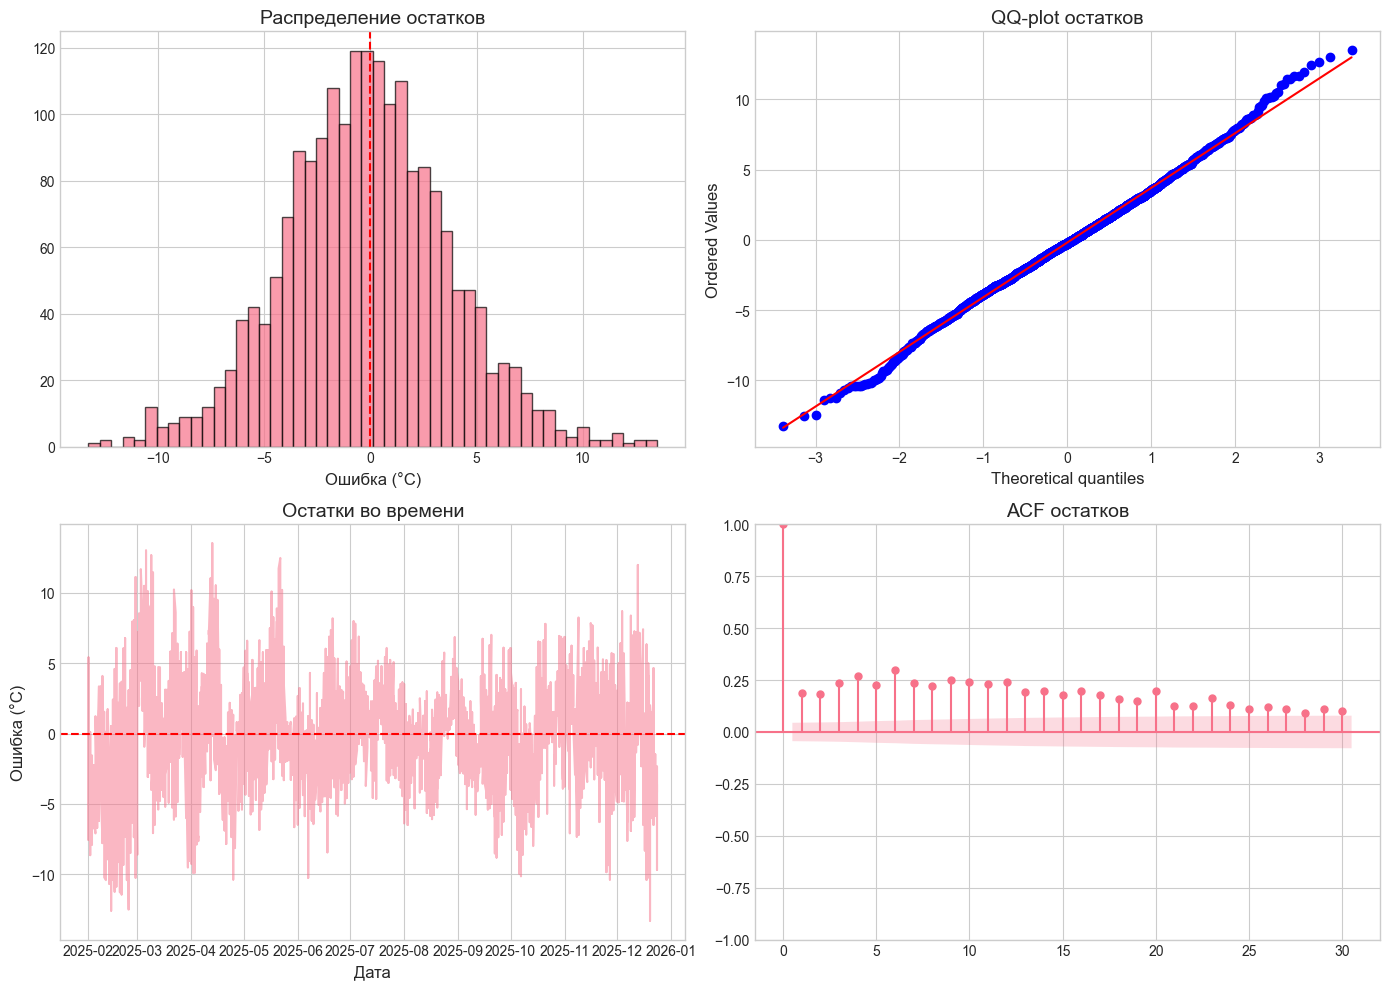

Среднее остатков:  -0.1881
Ст. отклонение:    3.8915
Минимум / Максимум: -13.2847 / 13.5044
Тест Шапиро-Уилка: p-value = 0.004115
Остатки НЕ нормальны


In [21]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

y_true_h7  = test['target_h7'].values
y_pred_h7  = direct_lgb[7].predict(test[features])
residuals  = y_true_h7 - y_pred_h7

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].set_title('Распределение остатков'); axes[0, 0].set_xlabel('Ошибка (°C)')

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot остатков')

axes[1, 0].plot(test['ds'].values, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Остатки во времени'); axes[1, 0].set_xlabel('Дата'); axes[1, 0].set_ylabel('Ошибка (°C)')

plot_acf(residuals, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout(); plt.show()

print(f"Среднее остатков:  {np.mean(residuals):.4f}")
print(f"Ст. отклонение:    {np.std(residuals):.4f}")
print(f"Минимум / Максимум: {np.min(residuals):.4f} / {np.max(residuals):.4f}")

sample_res   = residuals[:5000] if len(residuals) > 5000 else residuals
_, shapiro_p = stats.shapiro(sample_res)
print(f"Тест Шапиро-Уилка: p-value = {shapiro_p:.6f}")
print("Остатки приближены к нормальным" if shapiro_p > 0.05 else "Остатки НЕ нормальны")

## 14. Рейтинг моделей

In [22]:
summary = results_df.groupby('Model')[['MAE', 'RMSE', 'WAPE (%)', 'MAPE (%)', 'DirAcc (%)', 'DirR2', 'R2']].mean()
summary = summary.sort_values('MAE')

best_model  = summary.index[0]
worst_model = summary.index[-1]
naive_mae   = summary.loc['Naive (lag_1)', 'MAE'] if 'Naive (lag_1)' in summary.index else None
best_mae    = summary.loc[best_model, 'MAE']
improvement = ((naive_mae - best_mae) / naive_mae * 100) if naive_mae else None

direct_avg_mae    = results_df[results_df['Model'] == 'LGBM Direct']['MAE'].mean()
recursive_avg_mae = results_df[results_df['Model'] == 'LGBM Recursive']['MAE'].mean()

print(f"1. Лучшая модель:  {best_model}  (MAE = {best_mae:.3f} °C)")
print(f"2. Худшая модель:  {worst_model}  (MAE = {summary.loc[worst_model, 'MAE']:.3f} °C)")
if naive_mae:
    print(f"3. Naive MAE: {naive_mae:.3f} °C | Улучшение лучшей модели: {improvement:.1f}%")
print(f"4. LGBM Direct: {direct_avg_mae:.3f} °C | LGBM Recursive: {recursive_avg_mae:.3f} °C")
print(f"   Direct {'лучше' if direct_avg_mae < recursive_avg_mae else 'хуже'} на {abs(direct_avg_mae - recursive_avg_mae):.3f} °C")

1. Лучшая модель:  LGBM Direct  (MAE = 2.771 °C)
2. Худшая модель:  Naive (lag_1)  (MAE = 3.277 °C)
3. Naive MAE: 3.277 °C | Улучшение лучшей модели: 15.4%
4. LGBM Direct: 2.771 °C | LGBM Recursive: 2.878 °C
   Direct лучше на 0.107 °C


## 15. Итоговый отчет

### 1. Описание и первичный анализ данных
- Датасет `weather_data.xlsx` содержал данные на 8 листах, включая скрытые. С помощью `openpyxl` извлечены все листы; из них 3 содержали погодные данные.
- Исправлены: кодировка (latin1 → cp1251), опечатки в названиях городов, пустые строки и столбцы.
- Итоговый датафрейм: >370 тыс. строк, 6 городов.

### 2. Разведочный анализ данных (EDA)
- Визуализация температурных рядов всех 6 городов выявила ярко выраженную годовую сезонность с разной амплитудой.
- ADF-тест проведён по каждому городу: формально p < 0.05 у всех, что объясняется длиной выборки.
- Декомпозиция и ACF/PACF — по каждому городу отдельно. Благовещенск имеет наибольшую амплитуду сезонности; Сочи и Геленджик — наименьшую.
- Спектральный анализ (FFT) по всем городам подтвердил доминирование периода 365 дней.

### 3. Предобработка данных
- Агрегация к дневной частоте с правильными правилами: температура/влажность/давление — среднее, осадки/дождь/снег — сумма, `weathercode` — мода (самый частый код за день).
- Удалено 7 выбросов (IQR 1.5×), пропуски заполнены линейной интерполяцией.

### 4. Feature Engineering
- Реализован расширенный пайплайн: лаги температуры (1–14, 365), Fourier-признаки (k=1,2,3), rolling-статистики (7 и 30 дней), interaction-признаки.
- Добавлены признаки из `rain` и `snowfall`: лаги (1,2,7), скользящие суммы за 7 дней, бинарные флаги «был ли дождь/снег вчера».
- `weathercode` преобразован в 9 бинарных флагов по группам WMO (ясно / облачно / туман / морось / дождь / снег / ливни / снежные ливни / гроза) — числовой код самостоятельно не несёт линейной информации, флаги делают связь явной для деревьев.
- Предотвращена утечка данных: все текущие значения погодных параметров удалены, в модель поступают только прошлые.

### 5. Модели и стратегии
- Три алгоритма (Decision Tree, Random Forest, LightGBM) × две стратегии (Direct, Recursive) + Naive Baseline.
- Гиперпараметры подобраны через Optuna (TPE) для всех трёх моделей по среднему MAE на всех 7 горизонтах.
- Финальное обучение на train+val для максимального использования данных.

### 6. Метрики
- MAE, RMSE, WAPE, MAPE, Directional Accuracy, Directional R², R² — на тестовой выборке по каждому горизонту.
- LightGBM Direct стабильно лучше; Direct превосходит Recursive за счёт отсутствия накопления ошибки.

### 7. Выводы
- Расширение feature engineering за счёт `weathercode`, `rain`, `snowfall` добавляет информацию о типе погодного события, что особенно важно для зимних периодов и городов с резко континентальным климатом.
- Ошибка неизбежно растёт с горизонтом — физический предел предсказуемости атмосферных процессов.
- Пайплайн полностью воспроизводим и может быть расширен экзогенными признаками.